# 01 · matplotlib 入門：figure / axes 心智模型

歡迎來到 **程式實驗室 → Python → matplotlib 資料視覺化**。

這堂課不教你「背 API」，而是先建立一個正確的**心智模型**——搞懂 matplotlib 畫圖時，到底是誰在畫、畫在哪裡。把這個模型建立好，後面所有功能你都能自己推出來。

> 💡 這是一個可執行的 notebook。每個程式碼格子按左邊的 ▶️（或 `Shift+Enter`）就會跑。放心改數值、改參數、亂玩——你改的是自己的副本，不會動到原檔。

## 學習目標

- 分清楚 **Figure（畫布）** 和 **Axes（座標系）** 的差別
- 學會用 `plt.subplots()` 拿到這兩個物件
- 理解 **物件導向 (OO) 寫法** 與 **pyplot 寫法** 的差異，知道為什麼推薦前者
- 畫出你的第一張折線圖

## 1. 兩個核心物件：Figure 與 Axes

matplotlib 的圖由兩層組成，這是整個函式庫的地基：

| 物件 | 中文 | 是什麼 |
| --- | --- | --- |
| **Figure** | 畫布 | 最外層的容器，整張圖。一個 Figure 可以裝很多個 Axes。 |
| **Axes** | 座標系 | 真正畫資料的地方——有 x 軸、y 軸、刻度、標題。一個「子圖」就是一個 Axes。 |

用畫畫比喻：**Figure 是整張畫紙，Axes 是你在紙上框出來、實際作畫的那一格**。

⚠️ 注意：`Axes`（座標系，畫圖用）和 `axis`（單一條軸，x 或 y）是兩個不同的東西，別搞混。

## 2. 你的第一張圖（推薦的 OO 寫法）

`plt.subplots()` 會一次幫你建好一個 Figure 和一個 Axes，並回傳給你。之後所有操作都對著 `ax` 這個 Axes 物件下指令——清楚、可控。

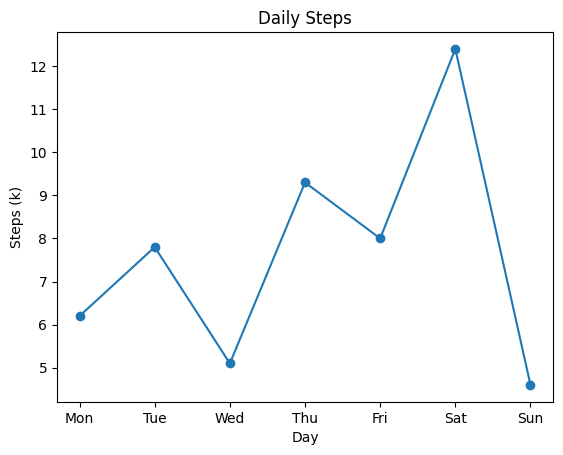

In [1]:
import matplotlib.pyplot as plt

# x 與 y 的資料（一週每天的步數，單位：千步）
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
steps = [6.2, 7.8, 5.1, 9.3, 8.0, 12.4, 4.6]

# 一次建立 figure（畫布）與 ax（座標系）
fig, ax = plt.subplots()

# 對著 ax 下指令：畫線、設標題與軸標籤
ax.plot(days, steps, marker="o")
ax.set_title("Daily Steps")
ax.set_xlabel("Day")
ax.set_ylabel("Steps (k)")

plt.show()

讀懂上面這段，你就掌握了 matplotlib 的核心節奏：

1. `fig, ax = plt.subplots()` —— 拿到畫布與座標系
2. `ax.plot(...)` —— 在座標系上畫資料
3. `ax.set_xxx(...)` —— 設定這個座標系的標題、軸標籤等
4. `plt.show()` —— 顯示出來

**動手試試**：把 `marker="o"` 改成 `marker="s"`（方形）或 `marker="^"`（三角形），再跑一次看看。

## 3. 另一種寫法：pyplot 風格（知道就好）

你在網路上會大量看到另一種寫法——直接呼叫 `plt.plot()`、`plt.title()`，不去碰 `ax`：


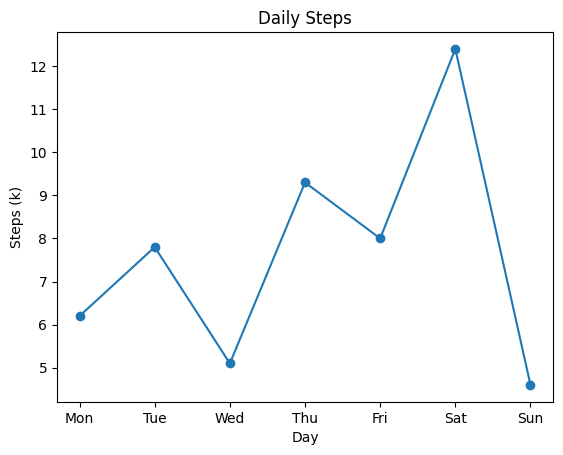

In [2]:
# pyplot 風格：matplotlib 在背後偷偷維護一個「目前的 Axes」，你的指令都打在它身上
plt.plot(days, steps, marker="o")
plt.title("Daily Steps")
plt.xlabel("Day")
plt.ylabel("Steps (k)")
plt.show()

結果一模一樣。差別在於：

- **pyplot 風格**：方便、字少，適合在 REPL 裡快速試。但「目前的 Axes」是隱藏狀態，一旦圖變複雜（多個子圖）就容易搞混到底在畫哪一格。
- **OO 風格（`ax.xxx`）**：每個指令都明確指定對象，圖再複雜都不會亂。

👉 **本系列一律用 OO 風格**，這也是 matplotlib 官方文件的建議。

## 4. 為什麼要分這麼清楚？因為一張畫布能放很多座標系

`plt.subplots(列數, 欄數)` 可以一次切出多個 Axes，這時候 OO 寫法的好處就出來了——每一格都是獨立的物件。

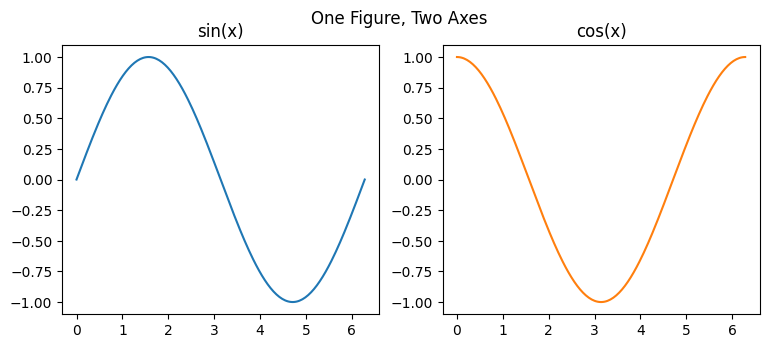

In [3]:
import numpy as np

x = np.linspace(0, 2 * np.pi, 200)

# 一張畫布、兩個座標系（1 列 2 欄）
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# axes 是一個陣列，axes[0] 是左圖、axes[1] 是右圖
axes[0].plot(x, np.sin(x), color="tab:blue")
axes[0].set_title("sin(x)")

axes[1].plot(x, np.cos(x), color="tab:orange")
axes[1].set_title("cos(x)")

fig.suptitle("One Figure, Two Axes")
plt.show()

看到關鍵了嗎？`fig.suptitle()` 設定的是**整張畫布**的大標題，而 `axes[0].set_title()` 設定的是**單一座標系**的標題。Figure 和 Axes 的分工在這裡一目了然。

## 小結

- **Figure = 畫布**，**Axes = 真正畫圖的座標系**，一個 Figure 可裝多個 Axes。
- 用 `fig, ax = plt.subplots()` 同時拿到兩者。
- 優先用 **OO 寫法**（`ax.plot`、`ax.set_title`…），狀態明確、不怕圖變複雜。
- 多子圖用 `plt.subplots(列, 欄)`，回傳的 `axes` 是陣列。

## 練習

1. 把第 2 節的折線圖改成 **2 列 1 欄** 的兩個子圖：上面畫 `steps`，下面畫每天步數的「累積總和」（提示：`np.cumsum(steps)`）。
2. 幫整張圖加一個 `fig.suptitle()`。

下一課我們會專心把**一條線**畫到好看——顏色、線型、標記、圖例一次搞懂。